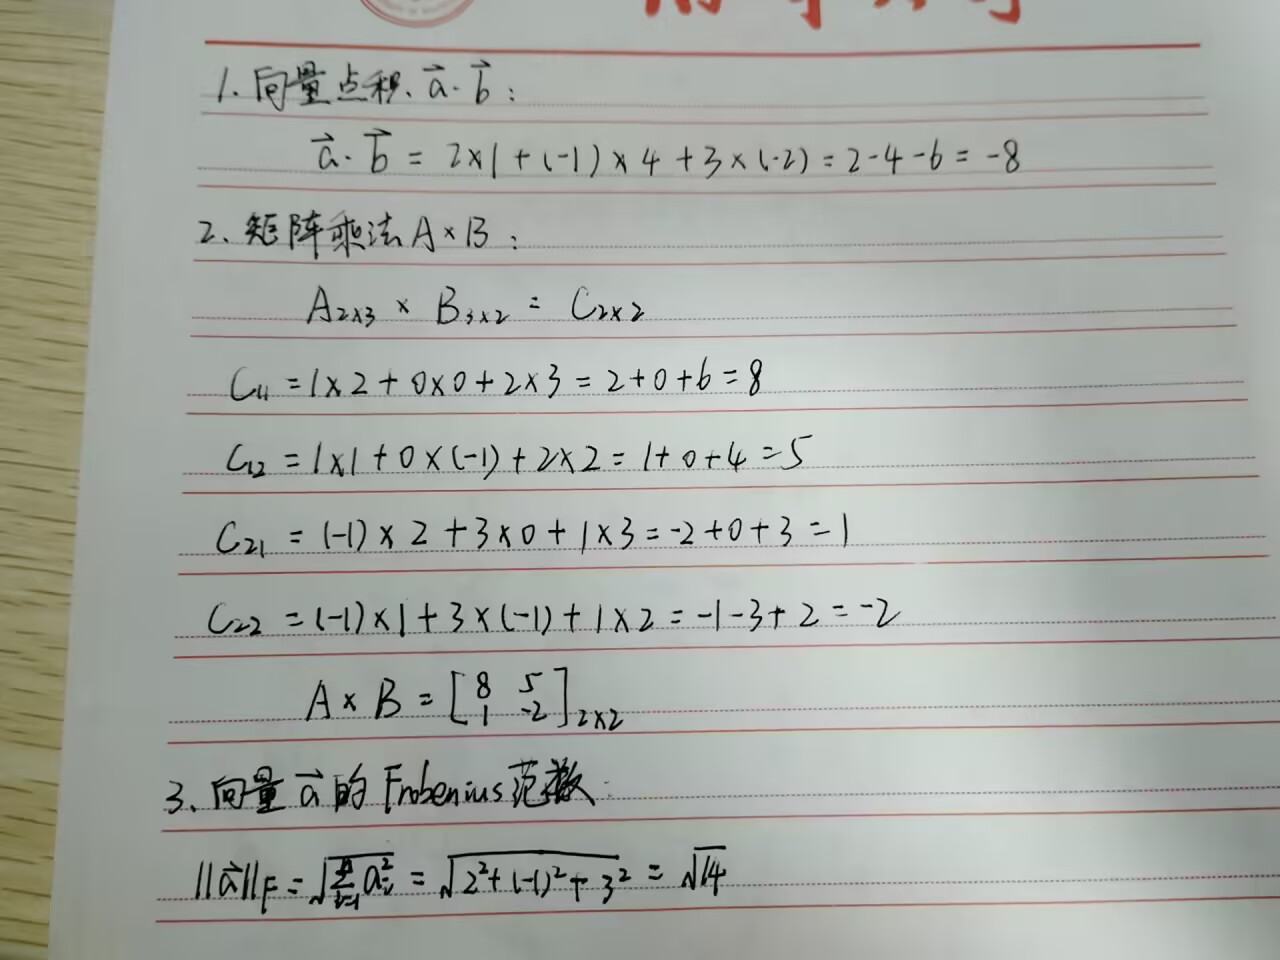

In [1]:
import numpy as np

# 1. 创建一个形状为 3x4 的随机矩阵 X，元素服从标准正态分布。
X = np.random.randn(3, 4)
print("1. 矩阵 X:\n", X)

# 2. 创建一个形状为 4x2 的全 1 矩阵 Y。
Y = np.ones((4, 2))
print("\n2. 矩阵 Y:\n", Y)

# 3. 计算矩阵乘法 Z = X * Y。
Z = np.dot(X, Y)  # 也可以使用 Z = X @ Y 
print("\n3. 矩阵 Z (X @ Y):\n", Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
# 第一行第二列对应索引 [0, 1]；第 2 行对应索引 [1, :]
elem_1_2 = Z[0, 1]
row_2 = Z[1, :]
print("\n4. 第一行第二列的元素:", elem_1_2)
print("   第 2 行的所有元素:", row_2)

# 5. 计算 Z 的 Frobenius 范数。
# np.linalg.norm 默认计算矩阵的 Frobenius 范数
f_norm = np.linalg.norm(Z)
print("\n5. Z 的 Frobenius 范数:", f_norm)

1. 矩阵 X:
 [[ 0.72052505 -1.32100815  0.39051993  0.06772788]
 [-0.43399112  0.46832551  1.26082344  0.42976029]
 [ 1.48065765  2.07260476  0.52606063  0.20298733]]

2. 矩阵 Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵 Z (X @ Y):
 [[-0.1422353  -0.1422353 ]
 [ 1.72491812  1.72491812]
 [ 4.28231038  4.28231038]]

4. 第一行第二列的元素: -0.14223529738150487
   第 2 行的所有元素: [1.72491812 1.72491812]

5. Z 的 Frobenius 范数: 6.532037288697567


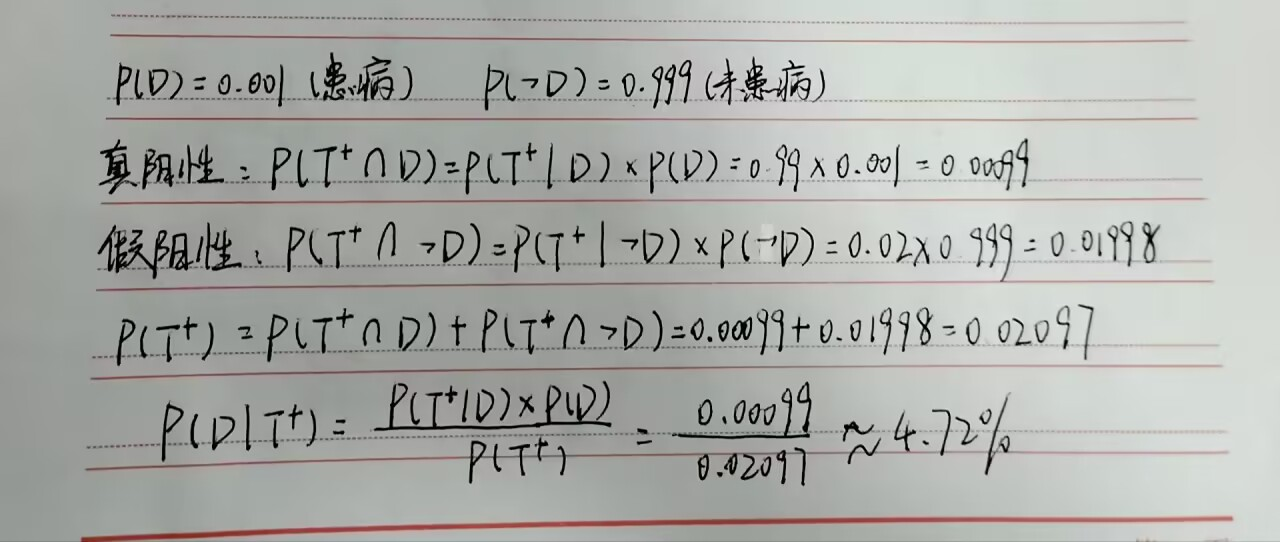

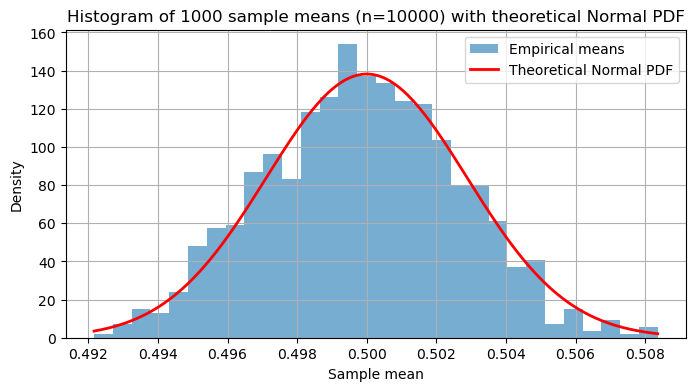


3.2 中心极限定理模拟结果:
实际均值的方差 (empirical variance): 7.779714e-06
理论方差 (1/12/n): 8.333333e-06


In [2]:
# 3.2 中心极限定理模拟
n = 10000  # 每次样本大小
m = 1000   # 重复次数

# 生成 m x n 的均匀分布样本，每行对应一次试验的 n 个样本
samples = np.random.rand(m, n)
means = samples.mean(axis=1)  # 每次试验的样本均值

import matplotlib.pyplot as plt

# 理论参数
mu = 0.5
sigma = np.sqrt((1/12) / n)  # 单个均匀(0,1)的方差为1/12，样本均值的方差为(1/12)/n

# 绘制直方图并叠加理论正态分布密度曲线
plt.figure(figsize=(8, 4))
plt.hist(means, bins=30, density=True, alpha=0.6, color='C0', label='Empirical means')

xs = np.linspace(means.min(), means.max(), 200)
pdf = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
plt.plot(xs, pdf, 'r-', lw=2, label='Theoretical Normal PDF')

plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.title(f'Histogram of {m} sample means (n={n}) with theoretical Normal PDF')
plt.legend()
plt.grid(True)
plt.show()

# 计算这些均值的实际方差
emp_var = means.var()  # 默认 ddof=0，计算总体方差
print("\n3.2 中心极限定理模拟结果:")
print(f"实际均值的方差 (empirical variance): {emp_var:.6e}")
print(f"理论方差 (1/12/n): {1/12/n:.6e}")

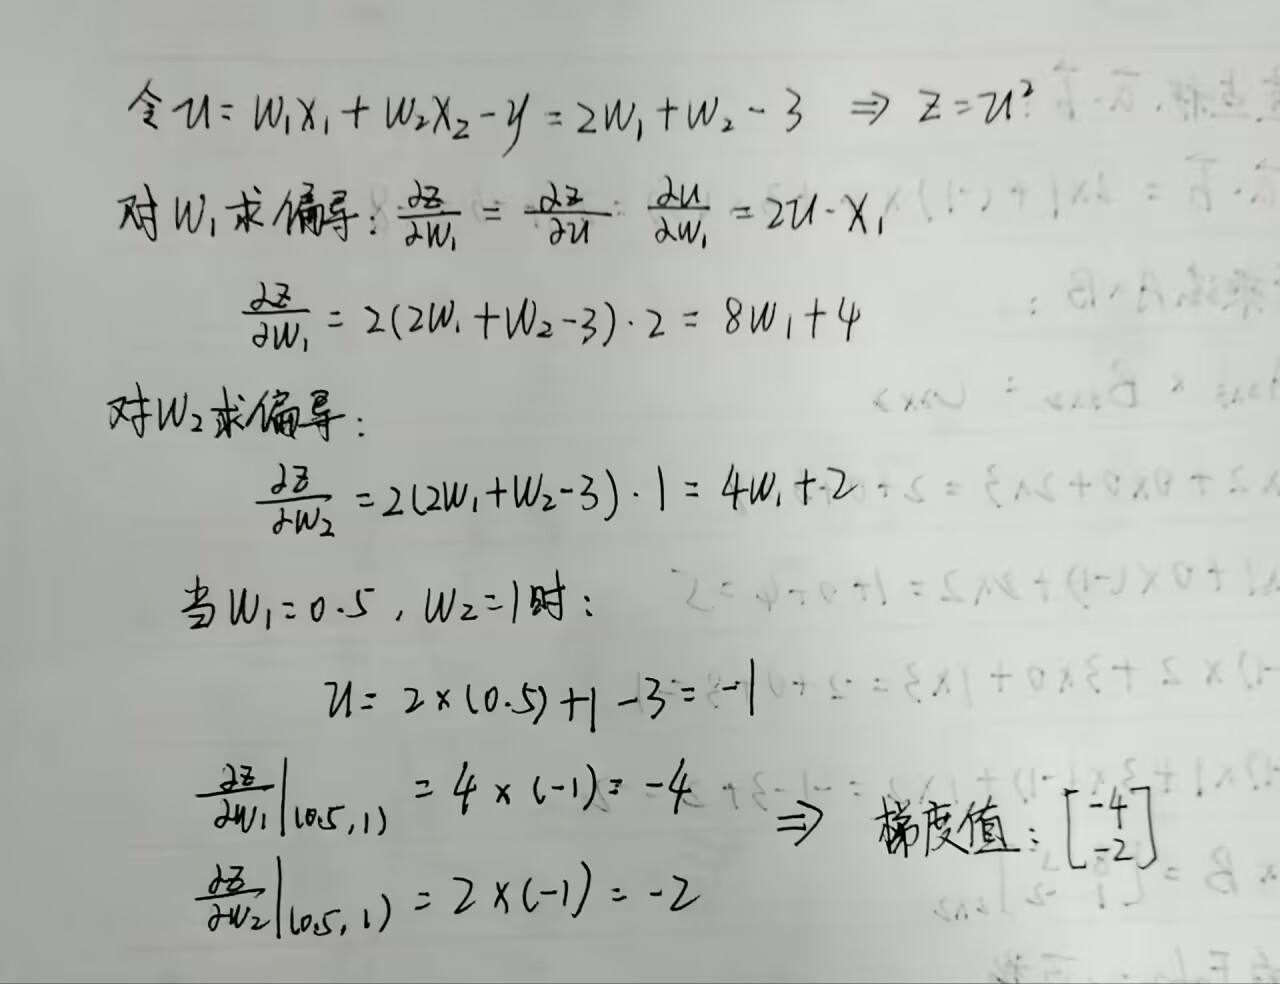

In [8]:
!pip install torch torchvision

import torch

# 手动实现简单计算图的反向传播
# 前向计算
x = 2
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

print("前向结果：")
print(f"a = {a}, b = {b}, L = {L}")

# 手动反向传播（链式法则）
# L = b^2, b = a + w2, a = x * w1
# dL/db = 2b
# db/da = 1, db/dw2 = 1
# da/dw1 = x

dL_db = 2 * b
db_da = 1
db_dw2 = 1
da_dw1 = x

# dL/dw2 = dL/db * db/dw2
dL_dw2 = dL_db * db_dw2

# dL/da = dL/db * db/da
dL_da = dL_db * db_da

# dL/dw1 = dL/da * da/dw1
dL_dw1 = dL_da * da_dw1

print("\n手动计算的梯度：")
print(f"dL/dw1 = {dL_dw1}")
print(f"dL/dw2 = {dL_dw2}")

# 使用自动微分工具验证

x_t = torch.tensor(2.0, requires_grad=False)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

L_t.backward()

print("\n自动微分工具计算的梯度：")
print(f"dL/dw1 = {w1_t.grad.item()}")
print(f"dL/dw2 = {w2_t.grad.item()}")

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 3.4 MB/s eta 0:00:02
   -------------- ------------------------- 1.6/4.3 MB 3.8 MB/s eta 0:00:01
   ------------------- -------------------- 2.1/4.3 MB 3.0 MB/s eta 0:00:01
   ---------------------- ----------------- 2.4/4.3 MB 2.9 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.3 MB 2.3 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.3 MB 2.3 MB/s eta 0:00:01
   --------------------------- ------------ 2.9/4.3 MB 2.1 MB/s eta 0:00:01
   ----------------------------- ---------- 3.1/4.3 MB 1.9 MB/s eta 0:00:01
   -------------------------------- ------- 3.4/4.3 MB 1.7 MB/s eta 0:00:01
   -------------------------------- ------- 3.4/4.3 MB 1.7 MB/s eta 0:00:01
   ---------------------

前向结果：
a = 3.0, b = 3.5, L = 12.25

手动计算的梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

自动微分工具计算的梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0


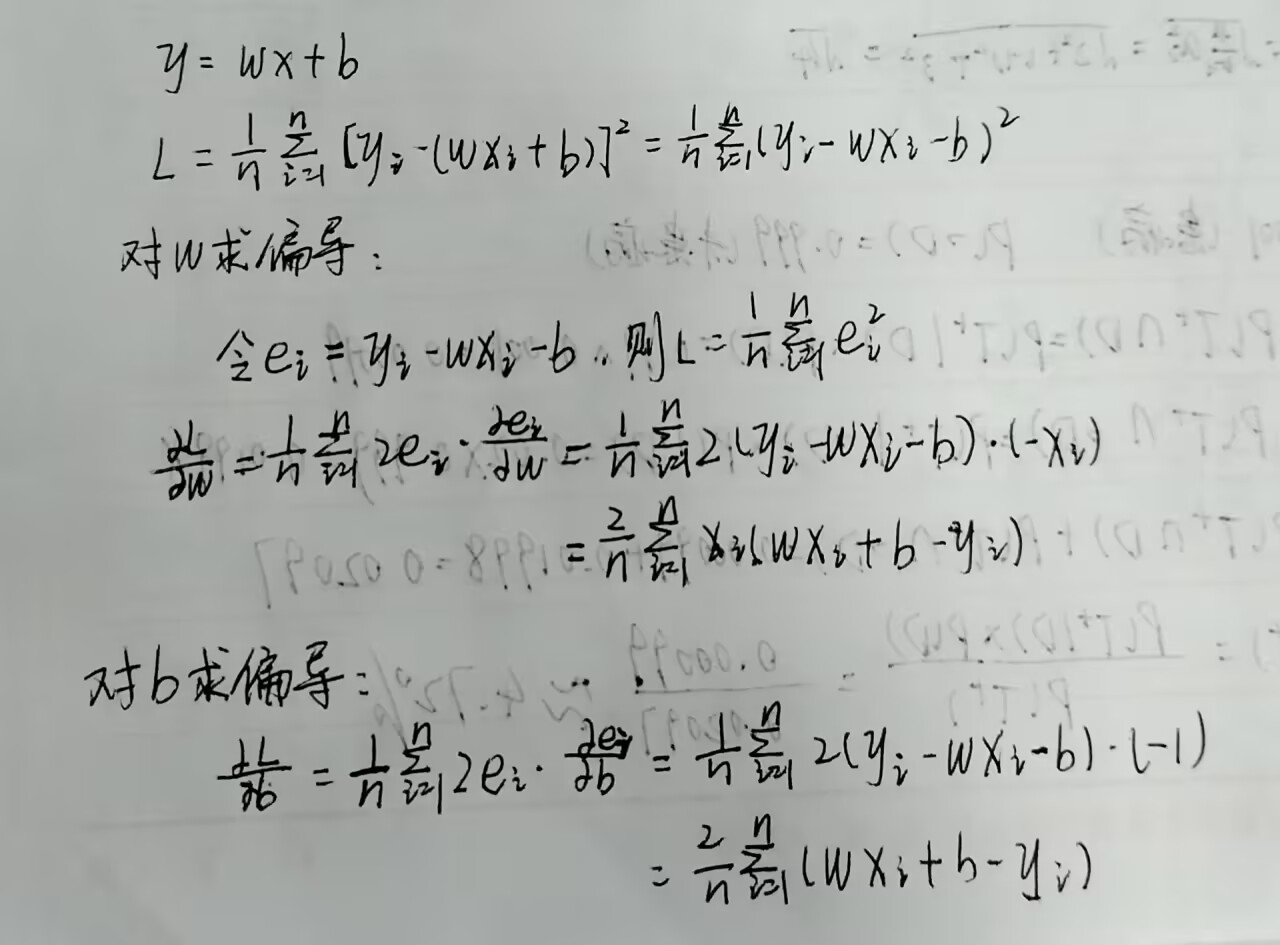

In [9]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载数据
digits = load_digits()
X = digits.data  # 已经是展平的 (n_samples, 64)
y = digits.target.reshape(-1, 1)

# 2. 标签 one-hot 编码
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 3. 实现 softmax 和交叉熵损失
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    # 防止 log(0)
    eps = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

# 4. 训练 softmax 回归
n_samples, n_features = X_train.shape
n_classes = y_train.shape[1]
np.random.seed(0)
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

batch_size = 32
lr = 0.1
epochs = 50

for epoch in range(epochs):
    # 打乱数据
    idx = np.random.permutation(n_samples)
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]
    for i in range(0, n_samples, batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        # 前向
        logits = np.dot(X_batch, W) + b
        y_pred = softmax(logits)
        # 损失
        loss = cross_entropy(y_pred, y_batch)
        # 反向
        grad_logits = (y_pred - y_batch) / X_batch.shape[0]
        grad_W = np.dot(X_batch.T, grad_logits)
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)
        # 更新
        W -= lr * grad_W
        b -= lr * grad_b
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 5. 测试集准确率
logits_test = np.dot(X_test, W) + b
y_pred_test = softmax(logits_test)
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
acc = np.mean(y_pred_labels == y_true_labels)
print(f"Test accuracy: {acc:.4f}")

Epoch 1, Loss: 1.7063
Epoch 10, Loss: 0.0029
Epoch 20, Loss: 0.0001
Epoch 30, Loss: 0.0004
Epoch 40, Loss: 0.0001
Epoch 50, Loss: 0.0000
Test accuracy: 0.9667


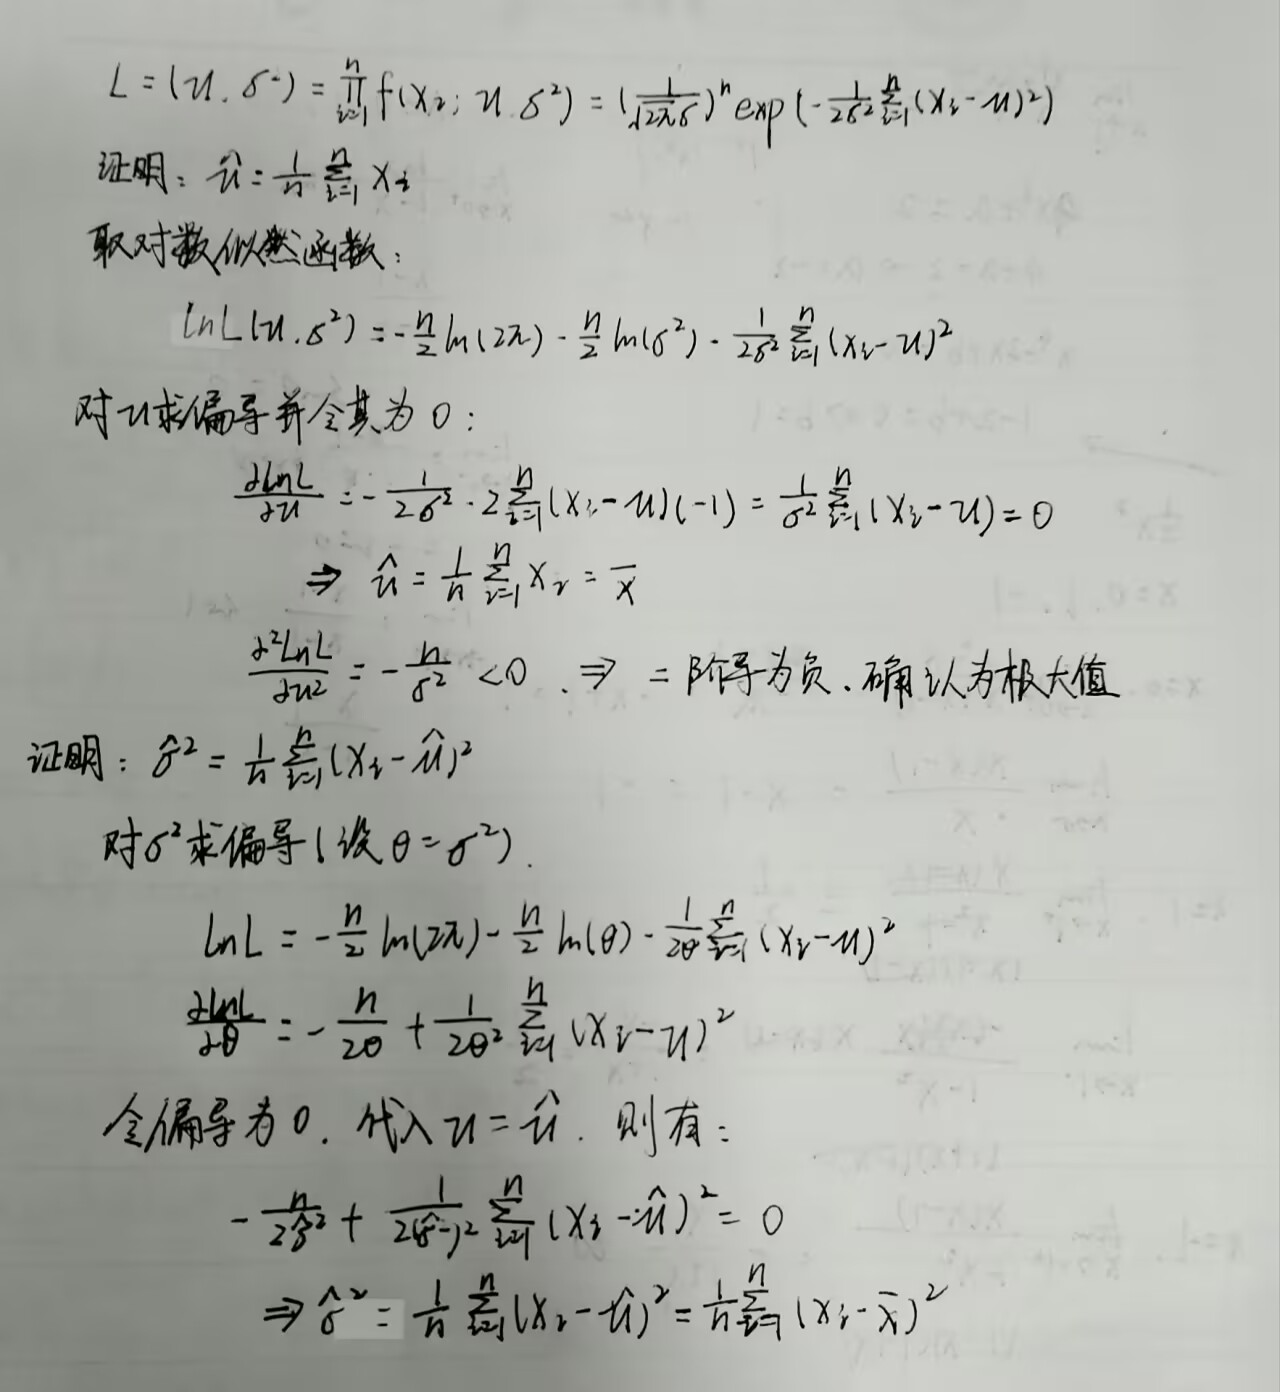

Epoch 200, Loss: 0.0215
Epoch 400, Loss: 0.0149
Epoch 600, Loss: 0.0121
Epoch 800, Loss: 0.0105
Epoch 1000, Loss: 0.0094


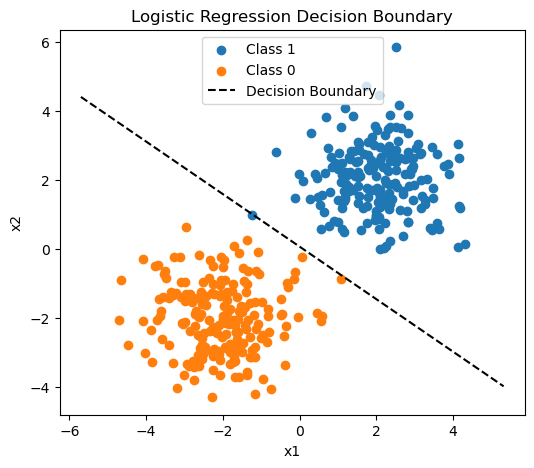

Test accuracy: 1.0000


In [7]:
# 1. 生成两类线性可分数据
np.random.seed(42)
n_train = 200
X1 = np.random.randn(n_train, 2) + np.array([2, 2])
X2 = np.random.randn(n_train, 2) + np.array([-2, -2])
X_train_bin = np.vstack([X1, X2])
y_train_bin = np.hstack([np.ones(n_train), np.zeros(n_train)]).reshape(-1, 1)

# 2. 定义sigmoid和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-9
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 3. 梯度下降法训练
w = np.zeros((2, 1))
b = 0.
lr = 0.1
epochs = 1000

for epoch in range(epochs):
    logits = np.dot(X_train_bin, w) + b
    y_pred = sigmoid(logits)
    loss = binary_cross_entropy(y_pred, y_train_bin)
    # 梯度
    grad_logits = y_pred - y_train_bin
    grad_w = np.dot(X_train_bin.T, grad_logits) / X_train_bin.shape[0]
    grad_b = np.mean(grad_logits)
    # 更新
    w -= lr * grad_w
    b -= lr * grad_b
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 4. 绘制决策边界
plt.figure(figsize=(6, 5))
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1')
plt.scatter(X2[:, 0], X2[:, 1], label='Class 0')
x_vals = np.linspace(X_train_bin[:,0].min()-1, X_train_bin[:,0].max()+1, 100)
y_vals = -(w[0]*x_vals + b)/w[1]
plt.plot(x_vals, y_vals.ravel(), 'k--', label='Decision Boundary')
plt.legend()
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# 5. 测试集准确率
X1_test = np.random.randn(50, 2) + np.array([2, 2])
X2_test = np.random.randn(50, 2) + np.array([-2, -2])
X_test_bin = np.vstack([X1_test, X2_test])
y_test_bin = np.hstack([np.ones(50), np.zeros(50)]).reshape(-1, 1)

logits_test = np.dot(X_test_bin, w) + b
y_pred_test = sigmoid(logits_test)
y_pred_labels = (y_pred_test >= 0.5).astype(int)
acc = np.mean(y_pred_labels == y_test_bin)
print(f"Test accuracy: {acc:.4f}")